**Import required libraries**

In [45]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

**Project paths**

In [46]:
CURRENT_DIR = os.getcwd()

PROJECT_ROOT = os.path.dirname(CURRENT_DIR)

DATASET_PATH = os.path.join(PROJECT_ROOT,"Datasets","SignLanguage")

MODELS_DIR = os.path.join(PROJECT_ROOT,"models")

print("Dataset Path:",DATASET_PATH)
print("Models Path:",MODELS_DIR)

Dataset Path: C:\Users\yuvra\AGE_GENDER_DETECTION\Datasets\SignLanguage
Models Path: C:\Users\yuvra\AGE_GENDER_DETECTION\models


**Gesture Classes**

In [47]:
classes = [
    "Hello",
    "Bye",
    "No",
    "Yes",
    "Perfect",
]

**Load Dataset Images**

In [48]:
images = []
labels = []

for label,gesture in enumerate(classes):

    folder = os.path.join(DATASET_PATH,gesture)

    for file in os.listdir(folder):

        img_path = os.path.join(folder,file)

        img = cv2.imread(img_path)

        img = cv2.resize(img,(64,64))

        images.append(img)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

print("Dataset shape:",X.shape)

Dataset shape: (345, 64, 64, 3)


**Normalize Images**

In [49]:
X = X / 255.0

**Train Test Split**

In [50]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**CNN Model**

In [51]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(5,activation='softmax'))

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         589,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 683,845 (2.61 MB)

 Trainable params: 683,845 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

In [52]:
history = model.fit(

    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test,y_test)

)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.4674 - loss: 1.3293 - val_accuracy: 0.8986 - val_loss: 0.4797
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9130 - loss: 0.3102 - val_accuracy: 0.9565 - val_loss: 0.0738
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9819 - loss: 0.0802 - val_accuracy: 0.9855 - val_loss: 0.0403
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9928 - loss: 0.0290 - val_accuracy: 0.9855 - val_loss: 0.0673
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 1.0000 - loss: 0.0130 - val_accuracy: 0.9855 - val_loss: 0.0937
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9928 - loss: 0.0211 - val_accuracy: 0.9855 - val_loss: 0.0555
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9928 - loss: 0.0112 - val_accuracy: 0.9855 - val_loss: 0.0396
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.9855 - val_loss: 0.0474

**Plot Accuracy**

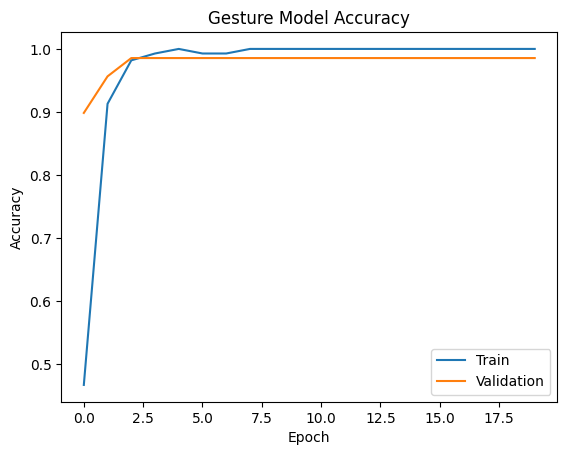

In [53]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Gesture Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

**Test with sample image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Predicted Gesture: Hello


(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

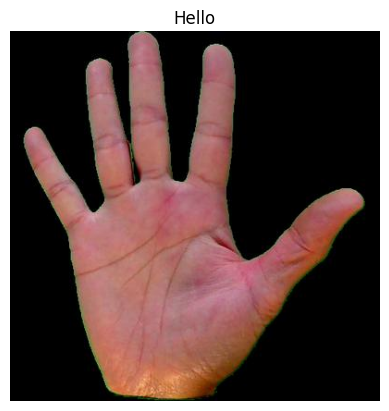

In [54]:
sample_path = os.path.join(DATASET_PATH,"Hello")

sample_img = os.listdir(sample_path)[0]

test_img_path = os.path.join(sample_path,sample_img)

test_img = cv2.imread(test_img_path)

img = cv2.resize(test_img,(64,64))

img = img / 255.0

img = img.reshape(1,64,64,3)

pred = model.predict(img)

gesture = classes[np.argmax(pred)]

print("Predicted Gesture:",gesture)

plt.imshow(cv2.cvtColor(test_img,cv2.COLOR_BGR2RGB))
plt.title(gesture)
plt.axis("off")

**Save the model**

In [55]:
os.makedirs(MODELS_DIR,exist_ok=True)

model.save(os.path.join(MODELS_DIR,"sign_language_model.h5"))

print("Model saved successfully")

Model saved successfully
